# F03 · Read a snippet without becoming a software engineer

<!-- paper-first -->
### Research question

**Reading:** [PD01](../../curriculum/papers/design.md#pd01). Review the assigned figure or result before starting the lesson.

**Question:** How could two short, valid snippets implement different scientific comparisons?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

<!-- key-references -->
### Why this technique matters

The most dangerous bugs in scientific Python are silent semantic errors that execute without raising exceptions—such as missing keepdims=True on square matrices, mutating shared-memory NumPy slice views in place, averaging across unmasked background zeros, or screening features before cross-validation (Kriegeskorte et al., 2009; Rosenblatt et al., 2024). Auditing code line-by-line as a mathematical contract prevents fabricated decoding accuracy and corrupted baselines.

**Key references** · *Forensic Python/NumPy code auditing: broadcasting semantics, domain guards, view vs. copy aliasing, mask indexing, and fold-isolated feature selection*

- *Foundational* — Kriegeskorte et al. (2009), [Circular analysis in systems neuroscience: the dangers of double dipping](https://doi.org/10.1038/nn.2303), *Nature Neuroscience*. Proves how selecting voxels or features using full-dataset statistics prior to evaluation fabricates spurious effects out of noise. Course library: [PD04](../../curriculum/papers/design.md#pd04).
- *Standard tool* — Abraham et al. (2014), [Machine learning for neuroimaging with scikit-learn](https://doi.org/10.3389/fninf.2014.00014), *Frontiers in Neuroinformatics*. Introduces the Nilearn masking contract (3D/4D volumes to 2D masked arrays) and fold-isolated scikit-learn Pipeline patterns for neuroimaging.
- *Standard tool* — Harris et al. (2020), [Array programming with NumPy](https://doi.org/10.1038/s41586-020-2649-2), *Nature*. Defines the canonical ndarray memory model, strided view vs. copy semantics, and right-aligned broadcasting rules underlying Python neuroimaging arrays.
- *Critical evaluation* — Rosenblatt et al. (2024), [Data leakage inflates prediction performance in connectome-based machine learning models](https://doi.org/10.1038/s41467-024-46150-w), *Nature Communications*. Quantifies how feature-selection, covariate, and subject-level leakage across cross-validation folds severely inflate neuroimaging prediction metrics.

Full entries, verification status and citation counts: [course bibliography](../../curriculum/papers/REFERENCES.md#f03).
<!-- /key-references -->

**Learning format:** predict $\to$ ask AI for one short operation $\to$ run $\to$ inspect $\to$ deliberately break $\to$ explain. Use Goose with a local Ollama model, or ChatGPT as a tutor and snippet writer. You are responsible for deciding whether the transformation answers the research question. Read the answer guide only after making your own prediction.

**Time:** 75 minutes. **Prerequisite:** F01.

---

### 1. Code Literacy as Mathematical & Scientific Auditing

You do not need to become a full-time software systems engineer to supervise neuroimaging code, but you must be able to **read a 10-line Python snippet as a formal mathematical specification**. When an AI coding assistant writes NumPy, SciPy, or `scikit-learn` code, its most dangerous mistakes are **silent semantic bugs**: code that runs without raising any exception, passes superficial shape checks, and produces plausible-looking plots while violating your scientific contract.

In this lesson, motivated by the analytical variability in [NARPS (`PD01`)](../../curriculum/papers/design.md#pd01), array-programming semantics in NumPy (Harris et al., 2020), neuroimaging pipeline abstractions in `scikit-learn` / Nilearn (Abraham et al., 2014), and the circular-analysis and data-leakage audits of [Kriegeskorte et al. (2009, `PD04`)](../../curriculum/papers/design.md#pd04), Kapoor & Narayanan (2023), and Rosenblatt et al. (2024), you will master the **Five Forensic Code Audits** required for every neuroimaging snippet:

| Forensic Audit | Core Python / NumPy Mechanism | Classic Silent Neuroimaging Bug | Supervisory Fix & Invariant Check |
|---|---|---|---|
| **1. Broadcasting & `keepdims`** | NumPy aligns shapes from the **trailing (rightmost) dimension** backward; dimensions of size `1` stretch to match (Harris et al., 2020). | Computing `baseline = X.mean(axis=1)` on shape `(V, T)` yields `(V,)`, which either crashes on `X - baseline` or silently subtracts row $j$'s mean from column $j$ if $V = T$. | Always specify `axis` explicitly and pass `keepdims=True` so `(V, T) - (V, 1)` broadcasts unambiguously along time. |
| **2. Domain Guards vs. Silent `NaN`/$\epsilon$ Hacks** | Division by zero or near-zero baseline (`abs(baseline) < 1e-8`) in background air or demeaned signals. | AI assistants often "fix" zero-division warnings by writing `baseline + 1e-8`, turning a demeaned noise fluctuation of `0.01` into a $10^8\%$ signal spike. | Raise an explicit `ValueError` when a physical contract (strictly positive baseline $\bar{x}_v > 0$) is violated, and restrict PSC to inside-brain masks. |
| **3. Views vs. Copies (In-Place Mutation)** | Basic slicing of a NumPy array (`roi = data[:10]`) returns a **shared-memory view**, and in-place operators (`-=`, `/=`) mutate the caller's original array. | A helper function `demean_inplace(X)` modifies raw data in memory; a later step that tries to compute Percent Signal Change on `raw_data` now divides by a zeroed baseline. | Convert inputs via `np.asarray(data, dtype=float).copy()` or use out-of-place expressions (`values - baseline`), and assert input immutability. |
| **4. Mask Indexing & Background Zeros** | A 3D NIfTI volume bounding box is typically $\sim 65\%\text{--}75\%$ empty air (`0.0`) outside the skull. | Calling `volume.mean()` or `volume.std()` on the full 3D array `(X, Y, Z)` averages in hundreds of thousands of air zeros, biasing whole-brain summary statistics downward by $3\text{--}5\times$. | Index explicitly with a boolean mask `volume[brain_mask > 0].mean()` before computing whole-brain summary statistics. |
| **5. Fitted Statistics & Leakage (`PD04`)** | Any data-derived quantity ($\hat{\mu}, \hat{\sigma}$, PCA axes, top-$K$ correlated features) is a **fitted parameter**. | Selecting top voxels/edges or standardizing across the *entire* dataset before `cross_val_score` leaks test distributions/labels into training (`PD04`; Kapoor & Narayanan, 2023; Rosenblatt et al., 2024). | Fit all scalers and feature selectors **strictly on `X_train` inside each fold** (e.g., via `sklearn.pipeline.Pipeline`), applying frozen `.transform(X_test)` to held-out participants. |

### 2. How to Read a Code Snippet as a 5-Column Mathematical Contract

When reading any scientific Python snippet, do not read it as English prose or trust variable names like `clean_signal` or `unbiased_accuracy`. Instead, trace a **five-column mental ledger** across every line of executable code:
1. **Symbol & Type:** Is the object a NumPy `ndarray` (`dtype=float64` vs. `int16`), a boolean mask (`dtype=bool`), a tuple of indices, or a fitted estimator object?
2. **Exact Tensor Shape & Axis Semantics:** Write the explicit tuple shape at the end of each line—e.g., `(V, T)` for `(voxels, timepoints)`, `(V, 1)` for a `keepdims=True` temporal reduction, or `(X, Y, Z)` for a 3D volumetric grid. Verify which physical dimension each axis index (`axis=0`, `axis=1`, `axis=-1`) represents.
3. **Physical Units & Reference Frame:** Track how units transform from raw scanner ADC units ($\text{a.u.}$) $\to$ centered change ($\Delta \text{ADC}$) $\to$ dimensionless Percent Signal Change ($\%\Delta S / \bar{S}$) or unitless standard deviations ($z$-score). If two arrays are added or subtracted, verify they share identical physical units and reference frames!
4. **Memory Aliasing & Mutability:** Does this line allocate a new array (`np.asarray(..., dtype=float).copy()`, arithmetic `a - b`), or does it create a **shared-memory view** (`arr[:10]`, `arr[:, idx]`) or mutate an input array in place (`-=`, `/=`, `arr[mask] = 0`)?
5. **Statistical Conditioning Set (Train vs. Test Provenance):** If a line computes a summary statistic (`mean`, `std`, `corrcoef`, `PCA`, `SelectKBest`), **which subjects or time points** entered that calculation? In any predictive or decoding workflow (`PD04`), any statistic computed before slicing `X[train_idx]` contaminates the test fold!

### 3. Supervisory Prompt for Code Line-by-Line Auditing

Whenever an assistant proposes a function, issue this exact prompt:
> **“Explain this snippet line by line using array shapes and physical units. Label every variable as: (a) raw input, (b) fixed hyperparameter, (c) fitted data statistic, or (d) transformed output. Identify whether the function mutates its input in place, state one assumption that could fail silently on real brain data, and construct a 5-line synthetic counterexample that exposes that failure.”**

For additional foundational practice with Python arrays and tables, see the [Berkeley Data 8 Python and arrays chapters](https://inferentialthinking.com/chapters/intro.html).


### Step 1 · Trace Each Line: Percent Signal Change and Explicit Domain Guards

The input `x` below contains $V = 2$ voxels (rows) and $T = 3$ time points (columns):
- Voxel 0 oscillates by $\pm 2$ ADC units around a baseline of $100$;
- Voxel 1 oscillates by $\pm 4$ ADC units around a baseline of $200$ (e.g., closer to the surface receive coil).

Before running the cell, trace each line of `percent_change(data, axis=-1)`:
- `values = np.asarray(data, dtype=float)` converts inputs to an IEEE-754 `float64` array so intermediate subtractions and multiplications on narrow integer NIfTI types (such as `int16` or `uint8`) cannot overflow or wrap around.
- `baseline = values.mean(axis=axis, keepdims=True)` collapses the time axis (`axis=-1`, length $3$) into a singleton dimension of length $1$, yielding shape `(2, 1)` with values `[[100.0], [200.0]]`.
- `if np.any(np.abs(baseline) < 1e-8): raise ValueError(...)` enforces the **scientific domain precondition** that every voxel has a strictly non-zero static reference baseline before dividing.
- `100 * (values - baseline) / baseline` subtracts `(2, 1)` from `(2, 3)` and divides elementwise by `(2, 1)`, normalizing away the $2\times$ multiplicative coil gain difference so both rows equal `[-2.0, 0.0, 2.0]`!


In [1]:
import numpy as np

def percent_change(data, axis=-1):
    values = np.asarray(data, dtype=float)
    baseline = values.mean(axis=axis, keepdims=True)
    if np.any(np.abs(baseline) < 1e-8):
        raise ValueError('Baseline too close to zero for percent change')
    return 100 * (values - baseline) / baseline

x = np.array([[98, 100, 102], [196, 200, 204]])
y = percent_change(x)
assert y.shape == x.shape and np.allclose(y[0], y[1])
assert np.allclose(y.mean(axis=-1), 0)
print(y)


[[-2.  0.  2.]
 [-2.  0.  2.]]


### Step 2 · Fail for an Understood Scientific Reason (vs. the AI "`+ 1e-8`" Antipattern)

What happens if a student or AI assistant feeds an **already centered signal** `[-1, 0, 1]` (whose mean is `0.0`) into `percent_change`?
1. Our contract raises an explicit `ValueError: Baseline too close to zero for percent change` because percentage change relative to baseline is **undefined** once the static baseline $\bar{x}_v$ has been subtracted!
2. Watch what happens if you accept a common AI "quick fix" that replaces the `ValueError` guard with `baseline + 1e-8`: the code runs without error and outputs **$\pm 10,000,000,000\%$** signal change!
3. Also verify in the code below that Percent Signal Change (`y`, in $\%$) and temporal $z$-scoring (`z`, in standard-deviation units) produce distinct numerical scales on `x`, and see Step 4 (Panel A) for how a tripled fluctuation amplitude (`v_base100_amp6` vs. `v_base100_amp2`) is preserved by Percent Signal Change but collapsed by $z$-scoring.


In [2]:
caught = False
try:
    percent_change([-1, 0, 1])
except ValueError as error:
    caught = True
    print(type(error).__name__ + ':', error)
assert caught

z = (x - x.mean(axis=-1, keepdims=True)) / x.std(axis=-1, keepdims=True)
assert not np.allclose(y, z)
print('Percent change and z score are different scales.')

# Demonstrate why the AI "+ 1e-8" epsilon fix is scientifically catastrophic on centered data
def bad_ai_psc_epsilon(data, axis=-1):
    values = np.asarray(data, dtype=float)
    baseline = values.mean(axis=axis, keepdims=True) + 1e-8
    return 100.0 * (values - baseline) / baseline

exploded_psc = bad_ai_psc_epsilon([-1.0, 0.0, 1.0])
assert np.max(np.abs(exploded_psc)) > 1e9
print('AI epsilon-hack output on centered [-1, 0, 1]:', exploded_psc)


ValueError: Baseline too close to zero for percent change
Percent change and z score are different scales.
AI epsilon-hack output on centered [-1, 0, 1]: [-1.00000001e+10 -1.00000000e+02  9.99999990e+09]


### Step 3 · Forensic Code Audits: In-Place Mutation, Square-Matrix Broadcasting, Mask Zeros, and Circular Leakage (`PD04`)

Let us now execute tiny, self-contained counterexamples for four pervasive bugs found in real neuroimaging scripts:
1. **The Square-Matrix Broadcasting Trap (`V == T`):** When $V = 4$ and $T = 4$, `X - X.mean(axis=1)` (missing `keepdims=True`) **does not raise a `ValueError`**—instead, NumPy right-aligns the `(4,)` row-mean vector with the trailing column axis (`axis=1`), subtracting row $j$'s mean from column $j$ across all rows.
2. **The In-Place Mutation Trap (`-= ` on a shared view):** Modifying an array slice in place (`roi = arr[:1]; roi -= ...`) corrupts the caller's upstream `raw_bold` tensor in memory.
3. **The Unmasked Air-Zero Trap:** Computing global brain intensity (`vol_3d.mean()`) without a mask includes $78.4\%$ background air zeros (`0.0`) and underestimates true brain tissue intensity by about $4.6\times$ ($108.0$ vs. $500.2$).
4. **Circular Double-Dipping (`PD04`; Rosenblatt et al., 2024):** Screening the top 20 correlated voxels across all $N = 60$ subjects before cross-validation fabricates $95.0\%$ mean decoding accuracy out of pure Gaussian noise ($50\%$ true chance).


In [3]:
# 1. Square-Matrix Broadcasting Trap (when V == T == 4, omitting keepdims=True fails SILENTLY!)
X_sq = np.array([[100., 102., 98., 100.],
                 [200., 204., 196., 200.],
                 [300., 306., 294., 300.],
                 [400., 408., 392., 400.]])
silent_broadcast_bug = X_sq - X_sq.mean(axis=1)           # Shape (4,4) - (4,) subtracts across columns!
correct_broadcast = X_sq - X_sq.mean(axis=1, keepdims=True)  # Shape (4,4) - (4,1) subtracts across rows!
assert silent_broadcast_bug.shape == X_sq.shape  # No crash!
assert not np.allclose(silent_broadcast_bug.mean(axis=1), 0.0)
assert np.allclose(correct_broadcast.mean(axis=1), 0.0)
print('Square matrix bug row means (should be 0!):', silent_broadcast_bug.mean(axis=1))

# 2. In-Place Mutation Bug vs. Defensive Copy
raw_bold = np.array([[100., 105., 95.], [200., 210., 190.]])
raw_backup = raw_bold.copy()
def buggy_demean_roi(arr):
    roi = arr[:1]  # Creates a memory VIEW into arr, not a copy!
    roi -= roi.mean(axis=-1, keepdims=True)
    return roi
_ = buggy_demean_roi(raw_bold)
assert not np.allclose(raw_bold, raw_backup)  # raw_bold[0] was silently destroyed in place!
print('Mutated raw_bold row 0 mean (corrupted to 0.0!):', raw_bold[0].mean())

# 3. Unmasked Background Zeros vs. Brain-Masked Mean
vol_3d = np.zeros((10, 10, 10))
brain_mask = np.zeros((10, 10, 10), dtype=bool)
brain_mask[2:8, 2:8, 2:8] = True  # 216 brain voxels out of 1000 (78.4% air zeros)
rng = np.random.default_rng(303)
vol_3d[brain_mask] = rng.normal(loc=500.0, scale=25.0, size=brain_mask.sum())
unmasked_mean = vol_3d.mean()
masked_mean = vol_3d[brain_mask].mean()
assert unmasked_mean < 150.0 and 490.0 < masked_mean < 510.0
print(f"3D Volume Mean -> Unmasked (air-contaminated): {unmasked_mean:.1f} vs Brain-Masked: {masked_mean:.1f}")

# 4. Circular Voxel Screening (Kriegeskorte PD04 Double Dipping) on Pure Null Noise
n_subj, n_vox = 60, 2000
X_null = rng.normal(size=(n_subj, n_vox))
y_null = np.repeat([0, 1], n_subj // 2)  # Pure coin-flip labels unrelated to X_null

# BUG: Screen top 20 voxels across ALL 60 subjects before splitting into train/test folds
corr_all = np.abs((X_null.T @ (y_null - y_null.mean())))
top_leaky_idx = np.argsort(corr_all)[-20:]
# Evaluate nearest-centroid classifier across 5 folds using leaky vs fold-isolated voxel screening
leaky_accs, clean_accs = [], []
indices = rng.permutation(n_subj)
for fold in range(5):
    test_mask = np.zeros(n_subj, dtype=bool)
    test_mask[indices[fold * 12:(fold + 1) * 12]] = True
    tr_mask = ~test_mask
    # Leaky evaluation (uses top_leaky_idx chosen on train + test)
    mu0_l = X_null[tr_mask & (y_null == 0)][:, top_leaky_idx].mean(axis=0)
    mu1_l = X_null[tr_mask & (y_null == 1)][:, top_leaky_idx].mean(axis=0)
    pred_l = (np.linalg.norm(X_null[test_mask][:, top_leaky_idx] - mu1_l, axis=1) <
              np.linalg.norm(X_null[test_mask][:, top_leaky_idx] - mu0_l, axis=1)).astype(int)
    leaky_accs.append(np.mean(pred_l == y_null[test_mask]))
    # Clean contract: screen top 20 voxels strictly inside tr_mask!
    corr_tr = np.abs(X_null[tr_mask].T @ (y_null[tr_mask] - y_null[tr_mask].mean()))
    top_clean_idx = np.argsort(corr_tr)[-20:]
    mu0_c = X_null[tr_mask & (y_null == 0)][:, top_clean_idx].mean(axis=0)
    mu1_c = X_null[tr_mask & (y_null == 1)][:, top_clean_idx].mean(axis=0)
    pred_c = (np.linalg.norm(X_null[test_mask][:, top_clean_idx] - mu1_c, axis=1) <
              np.linalg.norm(X_null[test_mask][:, top_clean_idx] - mu0_c, axis=1)).astype(int)
    clean_accs.append(np.mean(pred_c == y_null[test_mask]))

assert np.mean(leaky_accs) > 0.72 and 0.35 <= np.mean(clean_accs) <= 0.65
print(f"Null Noise Decoding Accuracy -> Leaky Pre-Screening (PD04 bug): {np.mean(leaky_accs):.1%} | Clean Fold-Isolated: {np.mean(clean_accs):.1%}")


Square matrix bug row means (should be 0!): [-150.  -50.   50.  150.]
Mutated raw_bold row 0 mean (corrupted to 0.0!): 0.0
3D Volume Mean -> Unmasked (air-contaminated): 108.0 vs Brain-Masked: 500.2
Null Noise Decoding Accuracy -> Leaky Pre-Screening (PD04 bug): 95.0% | Clean Fold-Isolated: 58.3%


### Step 4 · Visual Forensic Dashboard: Exposing Silent Code Bugs

Let us visualize all four code-reading audits in a 2x2 diagnostic figure so you can immediately recognize their visual signatures during code review:
- **Panel A:** Why Percent Signal Change preserves physical modulation differences ($\pm 2\%$ vs. $\pm 6\%$) while temporal $z$-scoring collapses both curves onto the exact same unit-variance trajectory.
- **Panel B:** Why omitting `keepdims=True` on a square matrix (`V == T == 4`) leaves non-zero post-centering row means (`[-150, -50, +50, +150]`).
- **Panel C:** How unmasked air zeros (`78.4%` of bounding-box voxels) pull the apparent whole-brain mean from `500.0` down to `~108.0`.
- **Panel D:** How circular feature pre-screening (`PD04`) inflates null noise decoding from `50%` true chance (`58.3%` fold-isolated mean) up to a `95.0%` mean across the 5 cross-validation folds.


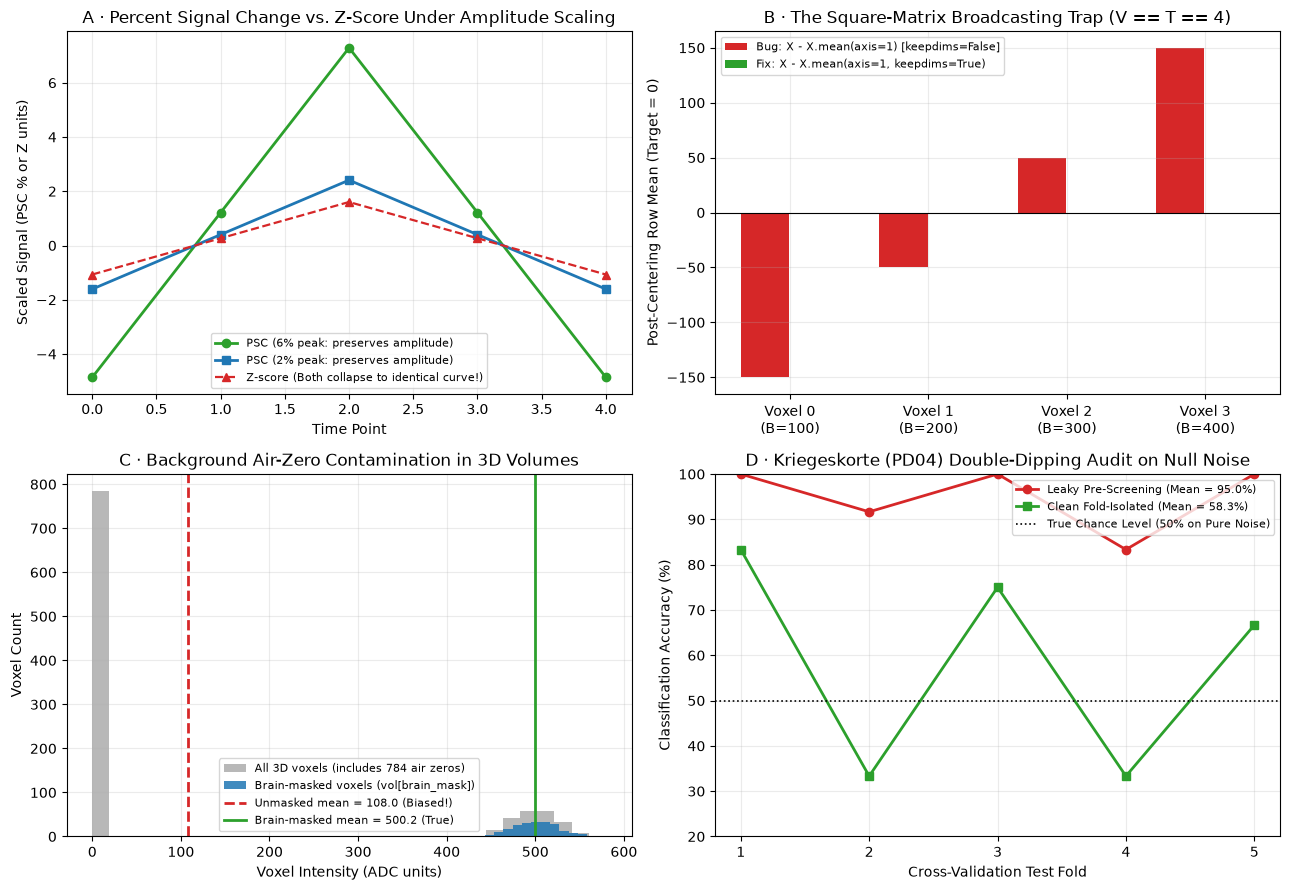

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: PSC vs Z-score when Voxel Amplitude Doubles vs Baseline Doubles
ax = axes[0, 0]
t_pts = np.arange(5)
v_base100_amp2 = np.array([98., 100., 102., 100., 98.])
v_base100_amp6 = np.array([94., 100., 106., 100., 94.])  # 3x amplitude, same baseline
psc_1 = percent_change(v_base100_amp2)
psc_2 = percent_change(v_base100_amp6)
z_1 = (v_base100_amp2 - v_base100_amp2.mean()) / v_base100_amp2.std()
z_2 = (v_base100_amp6 - v_base100_amp6.mean()) / v_base100_amp6.std()
ax.plot(t_pts, psc_2, 'o-', color='#2ca02c', lw=2, label='PSC (6% peak: preserves amplitude)')
ax.plot(t_pts, psc_1, 's-', color='#1f77b4', lw=2, label='PSC (2% peak: preserves amplitude)')
ax.plot(t_pts, z_1, '^--', color='#d62728', lw=1.6, label='Z-score (Both collapse to identical curve!)')
ax.set_title('A · Percent Signal Change vs. Z-Score Under Amplitude Scaling')
ax.set_xlabel('Time Point')
ax.set_ylabel('Scaled Signal (PSC % or Z units)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel B: Square-matrix broadcasting bug (keepdims=False vs keepdims=True)
ax = axes[0, 1]
voxels_idx = np.arange(4)
ax.bar(voxels_idx - 0.18, silent_broadcast_bug.mean(axis=1), width=0.35, color='#d62728', label='Bug: X - X.mean(axis=1) [keepdims=False]')
ax.bar(voxels_idx + 0.18, correct_broadcast.mean(axis=1), width=0.35, color='#2ca02c', label='Fix: X - X.mean(axis=1, keepdims=True)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(voxels_idx)
ax.set_xticklabels([f'Voxel {i}\n(B={100*(i+1)})' for i in voxels_idx])
ax.set_title('B · The Square-Matrix Broadcasting Trap (V == T == 4)')
ax.set_ylabel('Post-Centering Row Mean (Target = 0)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel C: Unmasked 3D bounding box (78% air zeros) vs Brain-Masked histogram
ax = axes[1, 0]
ax.hist(vol_3d.ravel(), bins=30, color='#7f7f7f', alpha=0.55, label='All 3D voxels (includes 784 air zeros)')
ax.hist(vol_3d[brain_mask], bins=15, color='#1f77b4', alpha=0.85, label='Brain-masked voxels (vol[brain_mask])')
ax.axvline(unmasked_mean, color='#d62728', ls='--', lw=2, label=f'Unmasked mean = {unmasked_mean:.1f} (Biased!)')
ax.axvline(masked_mean, color='#2ca02c', ls='-', lw=2, label=f'Brain-masked mean = {masked_mean:.1f} (True)')
ax.set_title('C · Background Air-Zero Contamination in 3D Volumes')
ax.set_xlabel('Voxel Intensity (ADC units)')
ax.set_ylabel('Voxel Count')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel D: Circular Feature Selection (PD04 Double Dipping) vs Fold-Isolated Screening
ax = axes[1, 1]
folds_x = np.arange(1, 6)
ax.plot(folds_x, np.array(leaky_accs) * 100, 'o-', color='#d62728', lw=2, label=f'Leaky Pre-Screening (Mean = {np.mean(leaky_accs):.1%})')
ax.plot(folds_x, np.array(clean_accs) * 100, 's-', color='#2ca02c', lw=2, label=f'Clean Fold-Isolated (Mean = {np.mean(clean_accs):.1%})')
ax.axhline(50.0, color='black', ls=':', lw=1.2, label='True Chance Level (50% on Pure Noise)')
ax.set_ylim(20, 100)
ax.set_xticks(folds_x)
ax.set_title('D · Kriegeskorte (PD04) Double-Dipping Audit on Null Noise')
ax.set_xlabel('Cross-Validation Test Fold')
ax.set_ylabel('Classification Accuracy (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Explain without AI

1. **Right-Aligned Broadcasting & `keepdims=True`:** Explain why `X - X.mean(axis=1)` raises a `ValueError` when `X` has shape `(2, 3)`, but **silently computes the wrong answer without any error** when `X` happens to be a square matrix of shape `(4, 4)`. How does `keepdims=True` prevent both failures?
2. **Why `+ 1e-8` Is Not a Scientific Fix:** Explain why adding a tiny constant `1e-8` to the denominator of `percent_change` is a mathematical and scientific bug when the baseline is zero or near-zero. What should a pipeline do instead when encountering zero-baseline background voxels or already demeaned time series?
3. **Amplitude vs. Variability Normalization:** In Panel A, why do `v_base100_amp2` ($\pm 2\%$) and `v_base100_amp6` ($\pm 6\%$) have different Percent Signal Change curves but **identical** $z$-score curves?
4. **Spotting Circular Leakage (`PD04`) in Code:** When reading an AI-generated machine-learning script, which exact ordering of lines tells you that feature selection or standardization leaked across the train/test boundary?

<details><summary>Answer guide</summary>

1. **Broadcasting Mechanics:** For shape `(V, T)`, `X.mean(axis=1)` drops axis 1 and returns shape `(V,)`. NumPy right-aligns `(V, T)` with `(1, V)`. If $V \neq T$, dimensions `T` and `V` clash and raise a `ValueError`. If $V == T == 4$, `(4, 4)` and `(1, 4)` match along the *columns*, so row $i$'s mean is subtracted from column $i$ across all rows! Passing `keepdims=True` preserves shape `(V, 1)`, which always aligns row-wise with `(V, T)`.
2. **Zero-Baseline Semantics:** Percent Signal Change is defined only relative to a positive physical reference intensity ($\bar{x}_v > 0$). If a signal has already been centered ($\bar{x}_v = 0$) or lies in background air, dividing by `1e-8` multiplies random thermal noise by $10^{10}$. The scientifically valid contract is to restrict PSC to inside-brain voxels (`mask > 0`) on uncentered raw/preprocessed intensities and raise a `ValueError` if fed demeaned data.
3. **PSC vs. $Z$-Score:** PSC divides by the temporal mean $\bar{x}_v = 100$, so tripling the oscillation amplitude triples the PSC ($\pm 2\% \to \pm 6\%$). $Z$-scoring divides by the time-series standard deviation $s_v$, which also triples when the oscillation triples—canceling the amplitude factor completely!
4. **Circular Leakage Signature (`PD04`):** Any line that calls `.mean()`, `.std()`, `.fit_transform()`, or `corrcoef(X, y)` on the full matrix `X` **before** indexing `X[train_idx]` vs. `X[test_idx]` inside the cross-validation loop leaks test-set information into feature selection or scaling.

</details>

**Submission:** Record the input, operation, parameters, output, one preserved property, one lost property, and the evidence that would make you reject the result. Include the prompt and any corrections you made to the generated code. A saved answer is not evidence of understanding until you can defend it orally.


<!-- agentic-guide -->
### Agentic Deliverable Supervision (F03 · macOS Goose + Ollama: Qwen & Gemma)

**Deliverable focus:** Forensic code-audit suite catching 5 silent neuroimaging snippet bugs (epsilon-hack PSC, square-matrix axis swap, in-place mutation, unmasked 3D volume mean, and pre-CV leakage).

#### 1. Suggestive Prompt (in the spirit of what to ask — adapt, do not copy verbatim)
> Ask Goose in the spirit of: *"Help me build a 5-part diagnostic test harness that demonstrates and repairs five silent AI coding bugs: (1) adding `1e-8` to compute percent signal change on an already-centered signal, (2) demeaning a square `(4, 4)` `(V, T)` matrix along the wrong axis, (3) mutating an input array in place (`-=`), (4) averaging a 3D volume without a brain mask, and (5) selecting top features before `KFold` on pure random noise."*

#### 2. What to Look For & How to Trace the Error Back Down
- **Immediate Red Flag:** Percent signal change explodes to $\pm 10^9\text{–}10^{10}\%$, the caller's raw BOLD array now has mean `0.0`, the whole-volume mean is $\sim 100$ instead of $\sim 500$, or pure noise classification reaches $75\text{–}90\%$ accuracy.
- **Traceback & Fix:** Trace each symptom to its contract violation: (1) raise a `ValueError` when $|\bar{x}_v| < \tau$ instead of dividing by `mean + 1e-8`; (2) test axis semantics on a non-square `(V=3, T=5)` array; (3) copy inputs (`arr = np.array(x, dtype=float, copy=True)`); (4) index by `vol[brain_mask > 0]`; (5) move `SelectKBest` inside `sklearn.pipeline.Pipeline`.

#### 3. Expected Outcome Range & Why It Must Look That Way
**Expected Range:** In a 3D volume where in-brain voxels ($\sim 20\text{–}25\%$ of the bounding box) average $\approx 500$ a.u. and surrounding air voxels ($75\text{–}80\%$) are $\approx 0$, the unmasked mean drops into $[95, 130]$ a.u. while the masked brain mean stays in $[490, 510]$ a.u.; on pure noise ($N=40, P=500$), leaky pre-CV screening yields accuracy in $[0.75, 0.95]$ whereas fold-isolated pipeline accuracy centers near chance ($[0.42, 0.58]$). **Why:** Including $78\%$ zero-valued air voxels dilutes the spatial mean by the brain occupancy fraction $f_{\text{brain}} \approx 0.216$, and screening $P \gg N$ noise features on all samples selects features whose random fluctuations align with the test labels.
<!-- /agentic-guide -->

### Return to the research question

Revisit [PD01](../../curriculum/papers/design.md#pd01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
